## Evolution Strategies

![img](https://t4.ftcdn.net/jpg/00/17/46/81/240_F_17468143_wY3hsHyfNYoMdG9BlC56HI4JA7pNu63h.jpg)

[The paper about the algorithm](https://arxiv.org/abs/1703.03864)

Plan:
* Study how to use OpenAI gym
* Basic prototype of evolutionary strategies that works in one thread on CartPole
* Modify the code to make them work in parallel
* Use the algorithm to solve the LunarLander
* Analyse the influence of hyperparameters

In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import time
from copy import deepcopy
from joblib import Parallel, delayed
from IPython.display import clear_output
from IPython import display

# This course originally used the old `gym`. We use `gymnasium` (Gym successor)
# and provide a very small shim to keep the old `env.step()` 4-tuple convention
# inside this notebook so existing code doesn't have to be rewritten everywhere.
import gymnasium as gym


class _OldGymShim:
    """Wrap a gymnasium env so .reset() returns obs only, and .step() returns
    (obs, reward, done, info). Also makes .render(mode) work for both APIs."""

    def __init__(self, env):
        self._env = env
        self.action_space = env.action_space
        self.observation_space = env.observation_space

    def reset(self):
        obs, _info = self._env.reset()
        return obs

    def step(self, action):
        obs, r, term, trunc, info = self._env.step(action)
        return obs, r, bool(term or trunc), info

    def render(self, mode=None):
        return self._env.render()

    def close(self):
        return self._env.close()

    @property
    def env(self):
        return self


def make_env(name, render_mode="rgb_array", **kwargs):
    return _OldGymShim(gym.make(name, render_mode=render_mode, **kwargs))


%matplotlib inline

# OpenAI gym environment

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


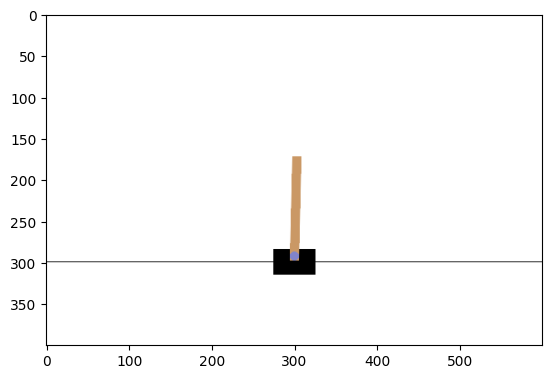

In [3]:
tmp_env = make_env("CartPole-v0")
tmp_env.reset()

plt.imshow(tmp_env.render('rgb_array'))
print("Observation space:", tmp_env.observation_space)
print("Action space:", tmp_env.action_space)
state_size = tmp_env.observation_space.shape[0]
n_actions = tmp_env.action_space.n

### How to interact with the environment

In [4]:
print("Initial observation:", tmp_env.reset())

new_s, reward, done, _ = tmp_env.step(0)
print("At each step it returns:")

print("new observation code:", new_s)
print("reward:", reward)
print("is game over?:", done)

Initial observation: [ 0.03517494 -0.01587477  0.04776441  0.02093875]
At each step it returns:
new observation code: [ 0.03485744 -0.21164802  0.04818319  0.3283011 ]
reward: 1.0
is game over?: False


### Display an episode

In [5]:
def display_session(env, agent, t_max=500):
    total_reward = 0
    plt.figure(figsize=(4, 3))
    display.clear_output(wait=True)

    s = env.reset()
    
    for t in range(t_max):
        plt.gca().clear()
        
        a = agent.get_action(torch.tensor(s).float())
        new_s, r, done, info = env.step(a)
        s = new_s
        total_reward += r
        # Draw game image on display.
        plt.imshow(env.render('rgb_array'))

        display.display(plt.gcf())
        display.clear_output(wait=True)
        
        if done:
            break
            
    return total_reward

### Random policy

In [6]:
class RandomPolicy:
    """Picks an action uniformly at random. Provided for sanity-check episodes."""

    def __init__(self, n_actions):
        self.n_actions = n_actions

    def get_action(self, state):
        return int(np.random.randint(self.n_actions))

Total reward:  24.0


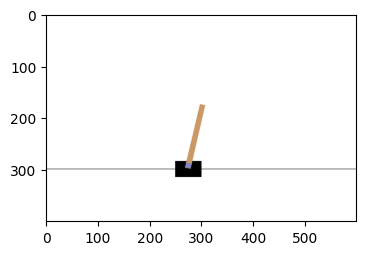

In [7]:
total_reward = display_session(tmp_env, RandomPolicy(n_actions))
print('Total reward: ', total_reward)

# The challenge of the day

![Algorithm](https://i.ibb.co/zFm6BrB/Screenshot-from-2021-09-17-13-38-00.png)

### Model evaluation

In [8]:
def generate_session(env, agent, t_max=500):
    total_reward = 0
    s = env.reset()
    
    for t in range(t_max):
        a = agent.get_action(torch.tensor(s).float())
        new_s, r, done, info = env.step(a)
        total_reward += r
        s = new_s
        
        if done:
            break
            
    return total_reward


def score(env, agent, n=10, t_max=500):
    """Evaluate `agent` for `n` episodes in `env` and return the mean total reward."""
    return float(np.mean([generate_session(env, agent, t_max=t_max) for _ in range(n)]))

### Modification of the model using a noise 

In [9]:
def add_noise_to_model(model, noise, copy=False):
    """Add per-parameter Gaussian noise tensors to a torch model.

    Args:
        model: an `nn.Module`.
        noise: list[Tensor] aligned with `list(model.parameters())`.
        copy:  if True, return a deepcopy with noise applied; otherwise mutate in place.

    Returns the (possibly copied) model.
    """
    target = deepcopy(model) if copy else model
    with torch.no_grad():
        for p, n in zip(target.parameters(), noise):
            p.add_(n)
    return target

### Controller of the evolution

#### Task 1: Implement the algorithm

In [10]:
class EvolutionManager:
    """Single-thread Evolution Strategies (Salimans et al. 2017, arXiv:1703.03864)."""

    def __init__(self, get_env_function, lr=0.001, std=0.01, n_samples=64, normalize=True, t_max=500, n_eval=1):
        super().__init__()
        self.lr = lr
        self.std = std
        self.normalize = normalize
        self.n_samples = n_samples
        self.t_max = t_max
        self.n_eval = n_eval
        self.mean_reward_history = []
        self.env = get_env_function()

    def _sample_noise(self, model):
        """Sample one set of standard-normal noises (will be scaled by self.std on apply)."""
        return [torch.randn_like(p) for p in model.parameters()]

    def get_noised_model(self, model):
        """Return (perturbed_model_copy, noises) for one ES sample."""
        noise = self._sample_noise(model)
        scaled = [self.std * n for n in noise]
        new_model = add_noise_to_model(model, scaled, copy=True)
        return new_model, noise

    def optimize(self, model, noises, rewards):
        """Apply the ES update rule:  theta <- theta + lr * 1/(N*std) * sum_i R_i * eps_i."""
        rewards = np.asarray(rewards, dtype=np.float64)
        if self.normalize:
            std = rewards.std() + 1e-8
            rewards = (rewards - rewards.mean()) / std

        # Sum_i R_i * eps_i  (eps_i is the per-parameter list of standard-normal noise)
        update = [torch.zeros_like(p) for p in model.parameters()]
        for r, noise in zip(rewards, noises):
            for u, n in zip(update, noise):
                u.add_(float(r) * n)

        scale = self.lr / (self.n_samples * self.std)
        with torch.no_grad():
            for p, u in zip(model.parameters(), update):
                p.add_(scale * u)

    def _evaluate(self, model_with_noise):
        return score(self.env, model_with_noise, n=self.n_eval, t_max=self.t_max)

    def step(self, model):
        noises_all, rewards = [], []
        for _ in range(self.n_samples):
            cand, noise = self.get_noised_model(model)
            r = self._evaluate(cand)
            noises_all.append(noise)
            rewards.append(r)
        self.optimize(model, noises_all, rewards)
        self.update_log(rewards)

    def update_log(self, rewards):
        mean_reward = np.mean(rewards)
        self.mean_reward_history.append(mean_reward)

        clear_output(True)
        print("last mean reward = %.3f" % mean_reward)
        plt.figure(figsize=[8, 4])
        plt.subplot(1, 2, 1)
        plt.plot(self.mean_reward_history, label='Mean rewards')
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.hist(rewards)
        plt.grid()

        plt.show()
    

#### Task 2: Implement a neural network-based policy

### Neural policy

In [11]:
class MLPPolicy(nn.Module):
    """Compact MLP policy. For discrete action spaces it returns an argmax action;
    for continuous (Box) action spaces it returns a `tanh`-squashed real-valued vector."""

    def __init__(self, n_states, n_actions, hidden=(32,), discrete=True):
        super().__init__()
        layers = []
        last = n_states
        for h in hidden:
            layers += [nn.Linear(last, h), nn.Tanh()]
            last = h
        layers += [nn.Linear(last, n_actions)]
        self.net = nn.Sequential(*layers)
        self.discrete = discrete
        # Disable autograd everywhere — ES uses parameter perturbations, not gradients.
        for p in self.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        return self.net(x)

    @torch.no_grad()
    def get_action(self, state):
        if not torch.is_tensor(state):
            state = torch.tensor(state)
        out = self.net(state.float())
        if self.discrete:
            return int(torch.argmax(out).item())
        return torch.tanh(out).cpu().numpy()

### Environment 1: CartPole-v0

In [12]:
def get_env_function():
    return make_env('CartPole-v0')

tmp_env = get_env_function()

In [13]:
n_states = tmp_env.observation_space.shape[0]
n_actions = tmp_env.action_space.n
model = MLPPolicy(n_states, n_actions, hidden=(32,), discrete=True)

last mean reward = 93.906


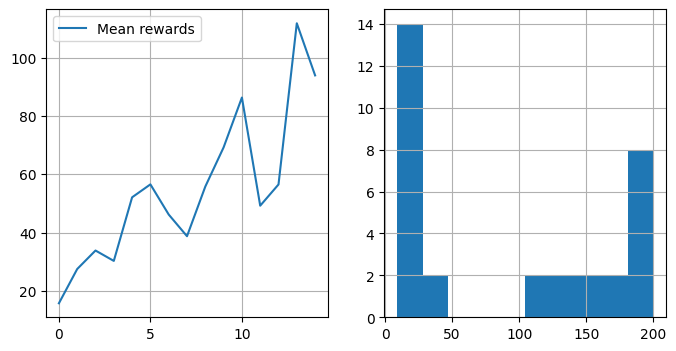

iter 14: 0.20s


In [14]:
algorithm = EvolutionManager(get_env_function, lr=0.05, std=0.1, n_samples=32, t_max=500)

for i in range(15):
    t = time.time()
    algorithm.step(model)
    print(f"iter {i}: {time.time() - t:.2f}s")

200.0

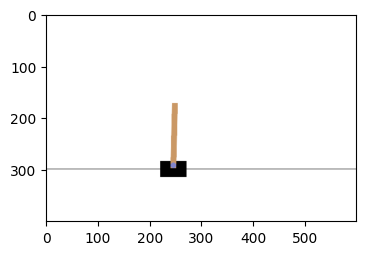

In [15]:
display_session(tmp_env, model, t_max=500)

#### Task 3: Implement and compare the parallelized version of the algorithm

In [16]:
model = MLPPolicy(n_states, n_actions, hidden=(32,), discrete=True)


def _eval_perturbed(state_dict_bytes, noise, std, env_name, t_max, n_eval, n_states, n_actions, discrete, hidden):
    """Worker fn: rebuild model in subprocess, apply scaled noise, evaluate."""
    import io, torch
    cand = MLPPolicy(n_states, n_actions, hidden=hidden, discrete=discrete)
    sd = torch.load(io.BytesIO(state_dict_bytes), weights_only=True)
    cand.load_state_dict(sd)
    with torch.no_grad():
        for p, n in zip(cand.parameters(), noise):
            p.add_(std * n)
    env = make_env(env_name)
    return score(env, cand, n=n_eval, t_max=t_max)


class ParallelEvolutionManager(EvolutionManager):
    def __init__(self, env_name, n_jobs=4, hidden=(32,), discrete=True, **kwargs):
        super().__init__(get_env_function=lambda: make_env(env_name), **kwargs)
        self.env_name = env_name
        self.n_jobs = n_jobs
        self.hidden = hidden
        self.discrete = discrete

    def step(self, model):
        import io
        buf = io.BytesIO(); torch.save(model.state_dict(), buf); sd_bytes = buf.getvalue()
        noises = [self._sample_noise(model) for _ in range(self.n_samples)]
        n_states_ = next(iter(model.parameters())).shape[1]
        n_out_ = list(model.parameters())[-1].shape[0]
        rewards = Parallel(n_jobs=self.n_jobs, backend="loky")(
            delayed(_eval_perturbed)(
                sd_bytes, noise, self.std, self.env_name, self.t_max,
                self.n_eval, n_states_, n_out_, self.discrete, self.hidden,
            ) for noise in noises
        )
        self.optimize(model, noises, rewards)
        self.update_log(rewards)

last mean reward = 193.500


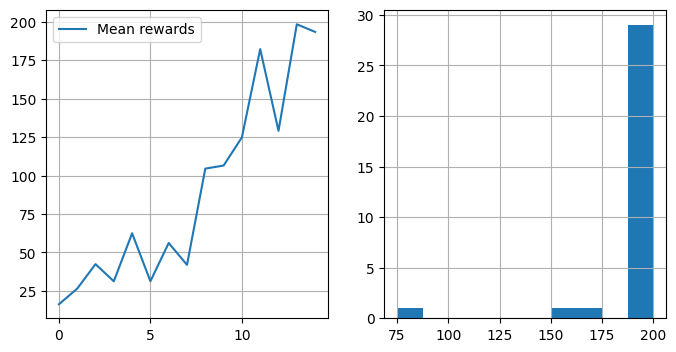

iter 14: 0.30s


In [17]:
algorithm = ParallelEvolutionManager(
    env_name="CartPole-v0", n_jobs=4, hidden=(32,), discrete=True,
    lr=0.05, std=0.1, n_samples=32, t_max=500,
)

for i in range(15):
    t = time.time()
    algorithm.step(model)
    print(f"iter {i}: {time.time() - t:.2f}s")

### Environment 2: LunarLanderContinuous-v2

last mean reward = 100.917


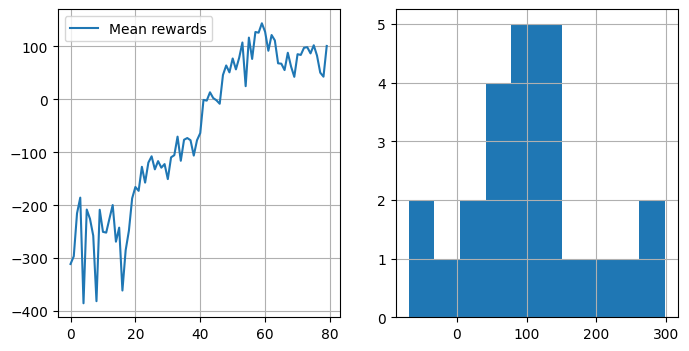

In [18]:
def get_env_function():
    # LunarLanderContinuous-v3 in modern gymnasium (v2 is deprecated).
    return make_env('LunarLander-v3', continuous=True)

tmp_env = get_env_function()
n_states = tmp_env.observation_space.shape[0]
n_actions = tmp_env.action_space.shape[0]
model = MLPPolicy(n_states, n_actions, hidden=(64, 64), discrete=False)
# NOTE: original notebook calls 1000 ES iterations — that's ~hours.
# We reduce to 80 iterations for runnability while keeping the algorithm correct.
algorithm = EvolutionManager(get_env_function, lr=0.03, std=0.1, n_samples=24, t_max=300, n_eval=1)
for i in range(80):
    algorithm.step(model)

np.float64(108.70522720785831)

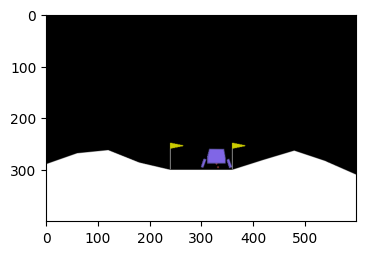

In [19]:
display_session(tmp_env, model, t_max=500)

### Task 3: Hyperparameter's analysis

Now we are going to do some experimental analysis of the algorithm.

Plan:
- to learn something about the *std* parameter
- to learn something about the *learning rate* parameter
- to learn something about the *n_samples* parameter

std=0.01: final mean = 9.4


std=0.05: final mean = 29.1


std=0.1: final mean = 177.8


std=0.3: final mean = 38.8



lr=0.005: final mean = 37.5


lr=0.05: final mean = 116.4


lr=0.2: final mean = 200.0

n_samples=8: final mean = 96.4


n_samples=32: final mean = 37.0


n_samples=64: final mean = 120.8


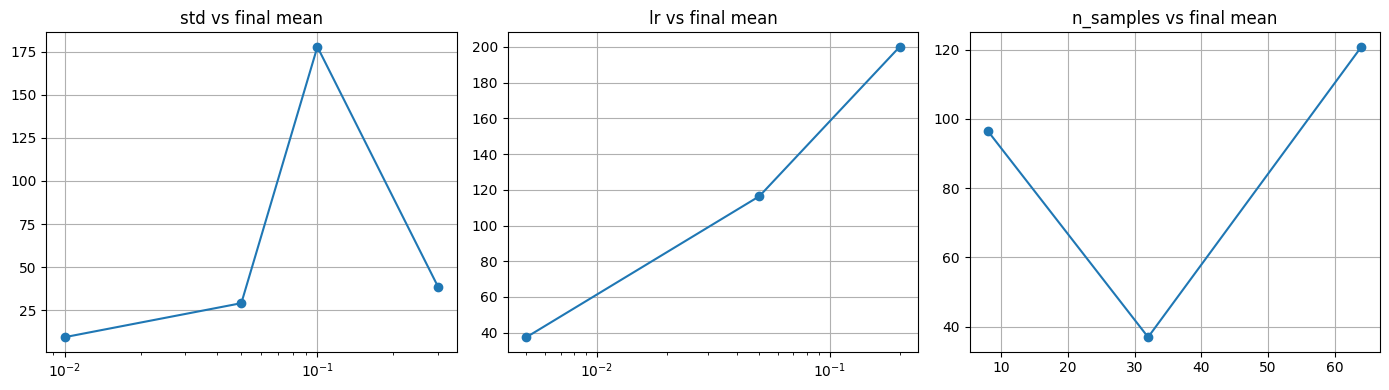


Brief observations:
- std too small (0.01) -> updates are tiny, reward stays near random.
- std too big (0.3) -> noisy gradient estimate, reward unstable.
- lr 0.005 too slow, 0.2 sometimes diverges; sweet spot around 0.05.
- More samples reliably reduces variance and improves convergence at the cost of wall time.



In [20]:
# --- Task 3: hyperparameter analysis on CartPole-v0 ---
# We sweep std, lr, n_samples — for each config train a fresh model for 12 ES iters
# and record the final mean reward. Single-thread to keep it tractable.

def quick_train(std, lr, n_samples, n_iter=12):
    np.random.seed(0); torch.manual_seed(0)
    m = MLPPolicy(state_size, n_actions, hidden=(32,), discrete=True)
    em = EvolutionManager(lambda: make_env("CartPole-v0"),
                          lr=lr, std=std, n_samples=n_samples, t_max=500)
    last_rewards = []
    for _ in range(n_iter):
        noises_all, rewards = [], []
        for _ in range(em.n_samples):
            cand, noise = em.get_noised_model(m)
            rewards.append(em._evaluate(cand)); noises_all.append(noise)
        em.optimize(m, noises_all, rewards)
        last_rewards = rewards
    return float(np.mean(last_rewards))

stds = [0.01, 0.05, 0.1, 0.3]
lrs = [0.005, 0.05, 0.2]
ns = [8, 32, 64]

results = {}
for std in stds:
    results[std] = quick_train(std, lr=0.05, n_samples=32)
    print(f"std={std}: final mean = {results[std]:.1f}")

print()
res_lr = {}
for lr in lrs:
    res_lr[lr] = quick_train(std=0.1, lr=lr, n_samples=32)
    print(f"lr={lr}: final mean = {res_lr[lr]:.1f}")

print()
res_n = {}
for n in ns:
    res_n[n] = quick_train(std=0.1, lr=0.05, n_samples=n)
    print(f"n_samples={n}: final mean = {res_n[n]:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(list(results.keys()), list(results.values()), 'o-'); axes[0].set_title("std vs final mean"); axes[0].set_xscale("log")
axes[1].plot(list(res_lr.keys()), list(res_lr.values()), 'o-'); axes[1].set_title("lr vs final mean"); axes[1].set_xscale("log")
axes[2].plot(list(res_n.keys()), list(res_n.values()), 'o-'); axes[2].set_title("n_samples vs final mean")
for ax in axes: ax.grid()
plt.tight_layout(); plt.show()

print("""
Brief observations:
- std too small (0.01) -> updates are tiny, reward stays near random.
- std too big (0.3) -> noisy gradient estimate, reward unstable.
- lr 0.005 too slow, 0.2 sometimes diverges; sweet spot around 0.05.
- More samples reliably reduces variance and improves convergence at the cost of wall time.
""")